In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import kagglehub

#  Download Dataset
path = kagglehub.dataset_download("muratkokludataset/rice-image-dataset")
base_dir = os.path.join(path, "Rice_Image_Dataset")



Using Colab cache for faster access to the 'rice-image-dataset' dataset.


In [2]:
# Listing the types of rice in the folder
categories = [f for f in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, f))]
print(f"Rice Images types {categories}")

data = []
for category in categories:
    folder_path = os.path.join(base_dir, category)
    images = os.listdir(folder_path)
    for img in images:
        data.append({
            'category': category,
            'path': os.path.join(folder_path, img)
        })

df = pd.DataFrame(data)
print(f"total images: {len(df)}")
df.head()

Rice Images types ['Karacadag', 'Basmati', 'Jasmine', 'Arborio', 'Ipsala']
total images: 75000


,category,path
0,Karacadag,/kaggle/input/rice-image-dataset/Rice_Image_Da...
1,Karacadag,/kaggle/input/rice-image-dataset/Rice_Image_Da...
2,Karacadag,/kaggle/input/rice-image-dataset/Rice_Image_Da...
3,Karacadag,/kaggle/input/rice-image-dataset/Rice_Image_Da...
4,Karacadag,/kaggle/input/rice-image-dataset/Rice_Image_Da...


In [3]:
print(df['category'].value_counts())

category
Karacadag    15000
Basmati      15000
Jasmine      15000
Arborio      15000
Ipsala       15000
Name: count, dtype: int64


Sampling Data

In [ ]:
sampled_df = df.groupby('category').apply(
    lambda x: x.sample(n=4000, random_state=42)
).reset_index(drop=True)

print(sampled_df['category'].value_counts())

category
Arborio      4000
Basmati      4000
Ipsala       4000
Jasmine      4000
Karacadag    4000
Name: count, dtype: int64


/tmp/ipykernel_55/3981581371.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby('category').apply(


/tmp/ipykernel_55/1481168868.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=sampled_df, x='category', palette='viridis')


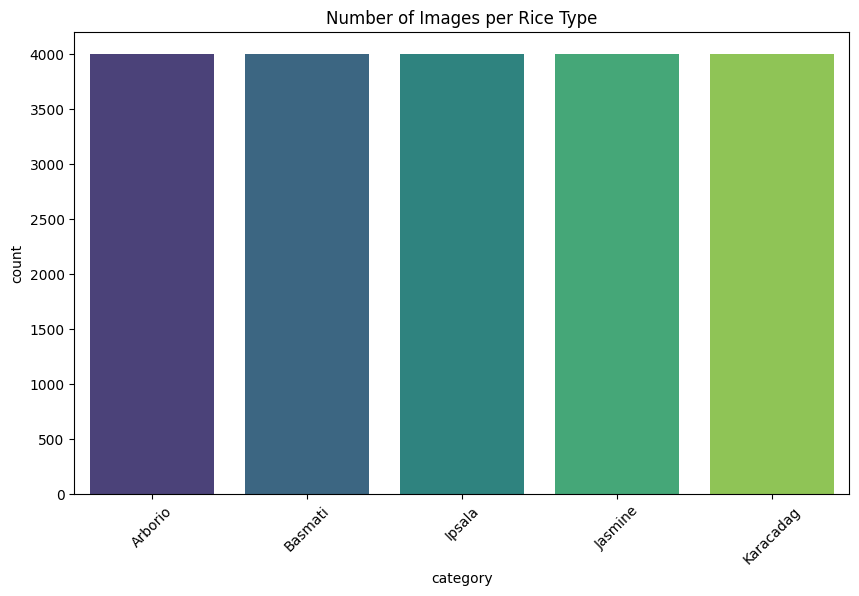

category
Arborio      4000
Basmati      4000
Ipsala       4000
Jasmine      4000
Karacadag    4000
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=sampled_df, x='category', palette='viridis')
plt.title('Number of Images per Rice Type')
plt.xticks(rotation=45)
plt.show()

# Checking the exact number of samples”
print(sampled_df['category'].value_counts())

Check Image Resolution

In [ ]:
# Sample 1 image from each class to check resolution
for category in categories:
    img_path = sampled_df[sampled_df['category'] == category]['path'].iloc[0]
    with Image.open(img_path) as img:
        print(f"{category} original size: {img.size}")

Karacadag original size: (250, 250)
Basmati original size: (250, 250)
Jasmine original size: (250, 250)
Arborio original size: (250, 250)
Ipsala original size: (250, 250)


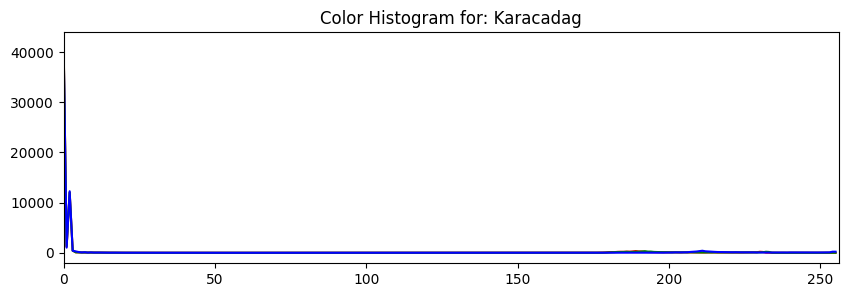

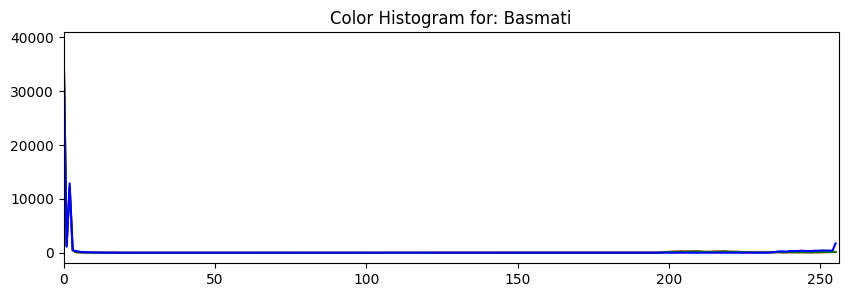

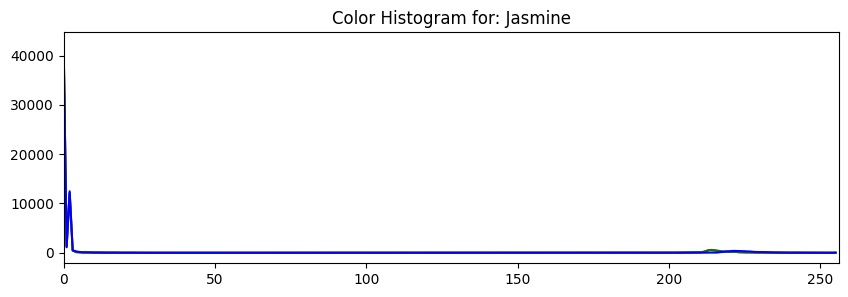

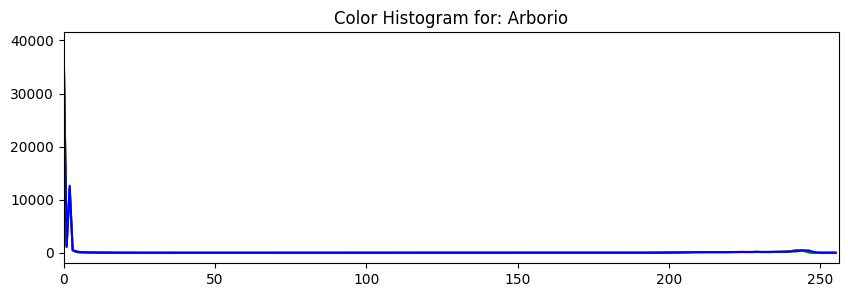

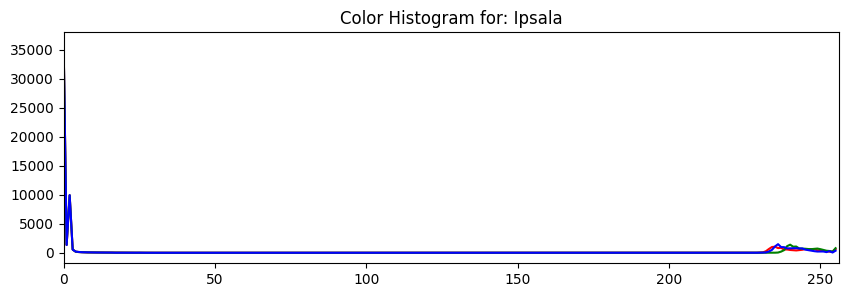

In [ ]:
def plot_color_distribution(img_path, category_name):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    colors = ('red', 'green', 'blue')
    plt.figure(figsize=(10, 3))
    for i, col in enumerate(colors):
        hist = cv2.calcHist([img], [i], None, [256], [0, 256])
        plt.plot(hist, color=col)
        plt.xlim([0, 256])
    plt.title(f'Color Histogram for: {category_name}')
    plt.show()

# Show one example image from each class
for category in categories:
    sample_img = sampled_df[sampled_df['category'] == category]['path'].iloc[0]
    plot_color_distribution(sample_img, category)

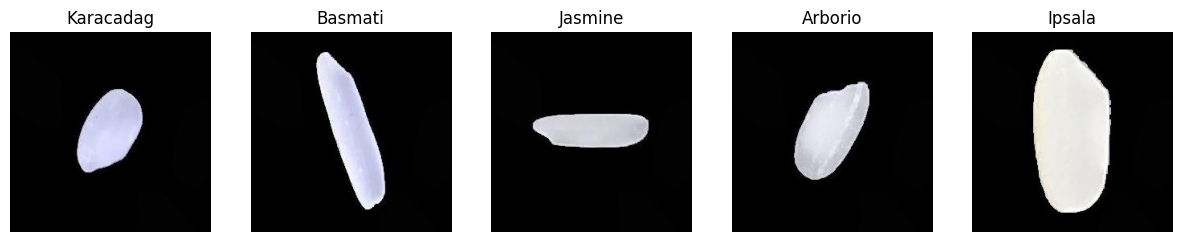

In [ ]:
plt.figure(figsize=(15, 8))
for i, category in enumerate(categories):
    folder_path = os.path.join(base_dir, category)
    img_name = os.listdir(folder_path)[0]
    img_path = os.path.join(folder_path, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(category)
    plt.axis('off')
plt.show()

Data Preprocessing

Splitting the Dataset

In [ ]:
from sklearn.model_selection import train_test_split

# Split 1: 70% Train, 30% Temp
train_df, temp_df = train_test_split(sampled_df, test_size=0.30, stratify=sampled_df['category'], random_state=42)

# Split 2: Divide Temp (30%) into two equal halves (15% Val, 15% Test)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['category'], random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 14000 | Val: 3000 | Test: 3000


Data Augmentation

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# --- 1. Configuration ---
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training generator with Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    brightness_range=[0.8, 1.2],
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation and Test generators (Rescale ONLY)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='path', y_col='category',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)

validation_gen = test_datagen.flow_from_dataframe(
    val_df, x_col='path', y_col='category',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

test_gen = test_datagen.flow_from_dataframe(
    test_df, x_col='path', y_col='category',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

2026-04-15 10:43:56.350369: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776249836.588779      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776249836.658738      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776249837.182654      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776249837.182705      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776249837.182708      55 computation_placer.cc:177] computation placer alr

Found 14000 validated image filenames belonging to 5 classes.
Found 3000 validated image filenames belonging to 5 classes.
Found 3000 validated image filenames belonging to 5 classes.


In [ ]:
for data_batch, labels_batch in train_gen:
    print('data batch shape:', data_batch.shape)
    print('labels batch shape:', labels_batch.shape)
    break
for data_batch, labels_batch in validation_gen:
    print('data batch shape:', data_batch.shape)
    print('labels batch shape:', labels_batch.shape)
    break
for data_batch, labels_batch in test_gen:
    print('data batch shape:', data_batch.shape)
    print('labels batch shape:', labels_batch.shape)
    break


data batch shape: (32, 224, 224, 3)
labels batch shape: (32, 5)
data batch shape: (32, 224, 224, 3)
labels batch shape: (32, 5)
data batch shape: (32, 224, 224, 3)
labels batch shape: (32, 5)


EarlyStopping Function

In [ ]:
my_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

Evaluation and Confusion Matrix Function

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(model, generator, model_name, class_names):
    print(f"\n==============================")
    print(f"Evaluating: {model_name}")
    print(f"==============================")

    # 1. SAFETY CHECK: Ensure the generator is NOT shuffling
    # This guarantees that y_true and y_pred align correctly.
    if hasattr(generator, 'shuffle'):
        generator.shuffle = False

    # Reset generator to the beginning
    generator.reset()

    # 2. Predictions
    # Using steps=len(generator) ensures we cover all images in the test set
    predictions = model.predict(generator, steps=len(generator), verbose=1)
    y_pred = np.argmax(predictions, axis=1)
    y_true = generator.classes

    # 3. Accuracy & F1 Score
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"\nFinal Test Accuracy: {acc:.4f}")
    print(f"Final F1 Score (Weighted): {f1:.4f}")

    # 4. Classification Report
    print(f"\n### Classification Report: {model_name} ###")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # 5. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Greens',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.xlabel('Predicted Rice Variety', fontsize=12)
    plt.ylabel('Actual Rice Variety', fontsize=12)
    plt.title(f'Confusion Matrix - {model_name}', fontsize=14)
    plt.show()

Learning Curve Function

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history, model_name="Model"):
    """
    Plots the Training vs Validation Accuracy and Loss.

    Args:
        history: The history object returned by model.fit()
        model_name: String name of the model for plot titles
    """
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Set up the figure with two subplots side-by-side
    plt.figure(figsize=(15, 5))

    # --- Accuracy Plot ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy', color='blue')
    plt.plot(epochs, val_acc, label='Validation Accuracy', color='orange')
    plt.title(f'Accuracy: {model_name}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # --- Loss Plot ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss', color='blue')
    plt.plot(epochs, val_loss, label='Validation Loss', color='orange')
    plt.title(f'Loss: {model_name}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# --- How to call the function ---


A1: CNN Baseline

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

def build_cnn_without_tuning():
    model = Sequential()

    # --- Feature Extraction Layers ---
    # First Convolutional block
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(64, activation='relu'))

    model.add(Dense(5, activation='softmax')) # Output layer (5 rice classes)

    # Compile the model
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
cnn_model = build_cnn_without_tuning()
history_cnn = cnn_model.fit(
    train_gen,
    validation_data=validation_gen,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1776249914.231460      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776249914.237090      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can i

Epoch 1/10


I0000 00:00:1776249918.184534     130 service.cc:152] XLA service 0x7fc07c0067e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776249918.184580     130 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776249918.184586     130 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776249918.513901     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/438 ━━━━━━━━━━━━━━━━━━━━ 34:55 5s/step - accuracy: 0.3125 - loss: 1.6342

I0000 00:00:1776249921.385221     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


438/438 ━━━━━━━━━━━━━━━━━━━━ 247s 553ms/step - accuracy: 0.6383 - loss: 1.0640 - val_accuracy: 0.9160 - val_loss: 0.2559
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 188s 429ms/step - accuracy: 0.8436 - loss: 0.3986 - val_accuracy: 0.9380 - val_loss: 0.1733
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 192s 439ms/step - accuracy: 0.8725 - loss: 0.3339 - val_accuracy: 0.9420 - val_loss: 0.1409
Epoch 4/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 197s 450ms/step - accuracy: 0.8881 - loss: 0.2859 - val_accuracy: 0.9723 - val_loss: 0.0885
Epoch 5/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 206s 469ms/step - accuracy: 0.8927 - loss: 0.2736 - val_accuracy: 0.9763 - val_loss: 0.0723
Epoch 6/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 204s 465ms/step - accuracy: 0.9065 - loss: 0.2399 - val_accuracy: 0.9690 - val_loss: 0.0931
Epoch 7/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 197s 449ms/step - accuracy: 0.9031 - loss: 0.2526 - val_accuracy: 0.9740 - val_loss: 0.0796
Epoch 8/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 201s 459ms/step - accuracy: 0.9090 - loss: 0.23

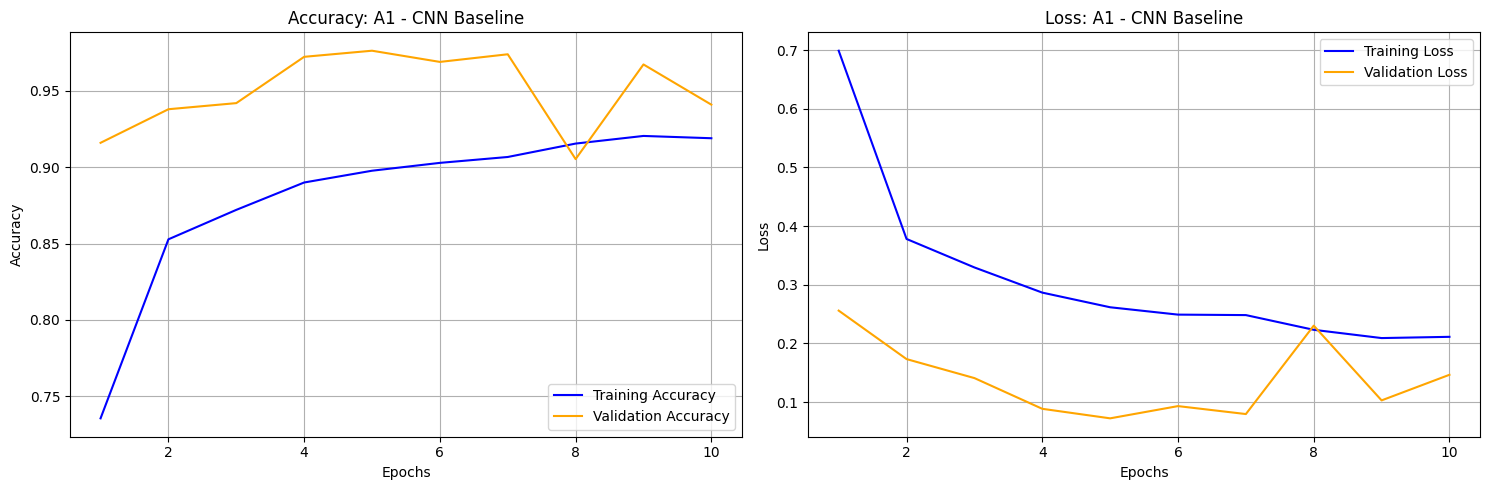

In [ ]:
plot_training_history(history_cnn, model_name="A1 - CNN Baseline")


Evaluating: A1 - CNN Baseline
94/94 ━━━━━━━━━━━━━━━━━━━━ 39s 415ms/step

Final Test Accuracy: 0.9453
Final F1 Score (Weighted): 0.9451

### Classification Report: A1 - CNN Baseline ###
              precision    recall  f1-score   support

   Karacadag       0.96      0.91      0.93       600
     Basmati       0.88      1.00      0.94       600
     Jasmine       0.97      1.00      0.99       600
     Arborio       0.93      0.86      0.89       600
      Ipsala       0.99      0.96      0.98       600

    accuracy                           0.95      3000
   macro avg       0.95      0.95      0.95      3000
weighted avg       0.95      0.95      0.95      3000



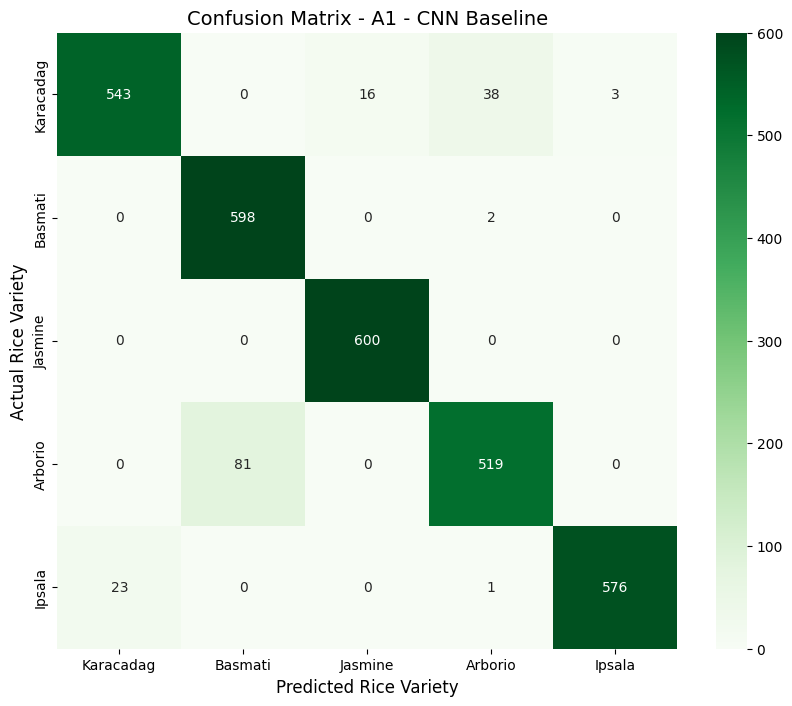

In [ ]:
evaluate_model(cnn_model, test_gen, "A1 - CNN Baseline", class_names=categories)

In [ ]:
cnn_model.save('cnn_model.h5')

CNN Tuned : A2

Hyperparameter Tuning

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def build_cnn_exp():
    model = Sequential()

    # Input layer + Block 1
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Block 2
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Classifier
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(5, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )


    return model

In [ ]:
cnn_exp_model = build_cnn_exp()

history_cnn_exp = cnn_exp_model.fit(
    train_gen,
    validation_data=validation_gen,
    epochs=10,
    callbacks=[my_early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10


2026-04-15 11:19:51.069384: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-15 11:19:51.219490: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


438/438 ━━━━━━━━━━━━━━━━━━━━ 221s 493ms/step - accuracy: 0.5713 - loss: 1.0461 - val_accuracy: 0.8690 - val_loss: 0.3077
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 206s 471ms/step - accuracy: 0.8123 - loss: 0.4698 - val_accuracy: 0.9450 - val_loss: 0.1505
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 212s 484ms/step - accuracy: 0.8653 - loss: 0.3456 - val_accuracy: 0.9410 - val_loss: 0.1432
Epoch 4/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 199s 453ms/step - accuracy: 0.8990 - loss: 0.2761 - val_accuracy: 0.8663 - val_loss: 0.3203
Epoch 5/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 204s 466ms/step - accuracy: 0.9156 - loss: 0.2272 - val_accuracy: 0.9263 - val_loss: 0.1837
Epoch 6/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 208s 475ms/step - accuracy: 0.9258 - loss: 0.2108 - val_accuracy: 0.9157 - val_loss: 0.2103
Epoch 7/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 200s 456ms/step - accuracy: 0.9327 - loss: 0.1937 - val_accuracy: 0.9767 - val_loss: 0.0712
Epoch 8/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 200s 457ms/step - accuracy: 0.9404 - loss: 0.16

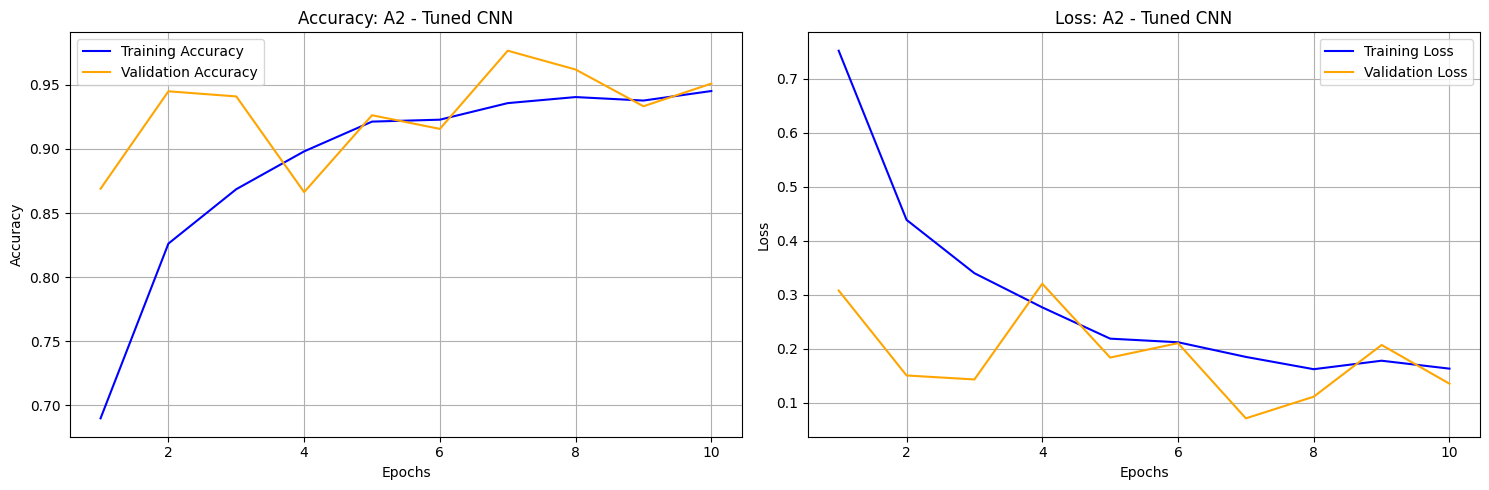

In [ ]:
plot_training_history(history_cnn_exp, model_name="A2 - Tuned CNN")


Evaluating: A2 - Tuned CNN
94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step

Final Test Accuracy: 0.9760
Final F1 Score (Weighted): 0.9760

### Classification Report: A2 - Tuned CNN ###
              precision    recall  f1-score   support

   Karacadag       0.97      0.96      0.97       600
     Basmati       0.96      0.99      0.98       600
     Jasmine       0.96      1.00      0.98       600
     Arborio       0.99      0.96      0.97       600
      Ipsala       1.00      0.97      0.98       600

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000



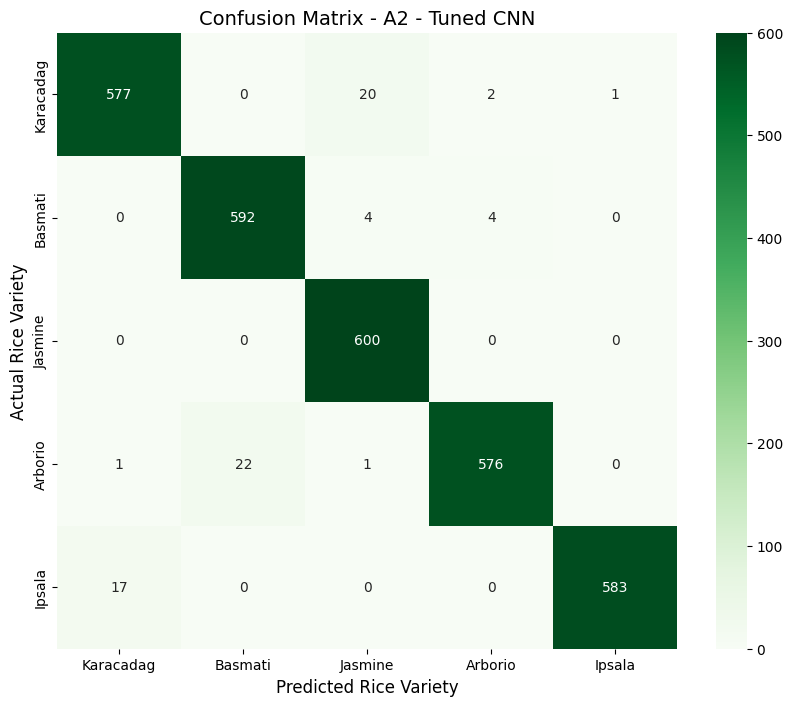

In [ ]:
evaluate_model(cnn_exp_model, test_gen, "A2 - Tuned CNN", class_names=categories)

CNN Tuned: A3

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def build_cnn_exp1():
    model = Sequential()

    # Input layer + Block 1
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Block 2
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Block 3
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Classifier
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(5, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )


    return model

In [ ]:
cnn_exp1_model = build_cnn_exp1()

history_cnn_exp1 = cnn_exp1_model.fit(
    train_gen,
    validation_data=validation_gen,
    epochs=15,
    callbacks=[my_early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 204s 455ms/step - accuracy: 0.5856 - loss: 0.9573 - val_accuracy: 0.9183 - val_loss: 0.2618
Epoch 2/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 198s 453ms/step - accuracy: 0.7684 - loss: 0.5451 - val_accuracy: 0.8900 - val_loss: 0.2691
Epoch 3/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 201s 458ms/step - accuracy: 0.8238 - loss: 0.4253 - val_accuracy: 0.7680 - val_loss: 0.6005
Epoch 4/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 197s 449ms/step - accuracy: 0.8471 - loss: 0.3763 - val_accuracy: 0.7383 - val_loss: 0.7369
Epoch 5/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 198s 452ms/step - accuracy: 0.8664 - loss: 0.3363 - val_accuracy: 0.4973 - val_loss: 2.4020
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


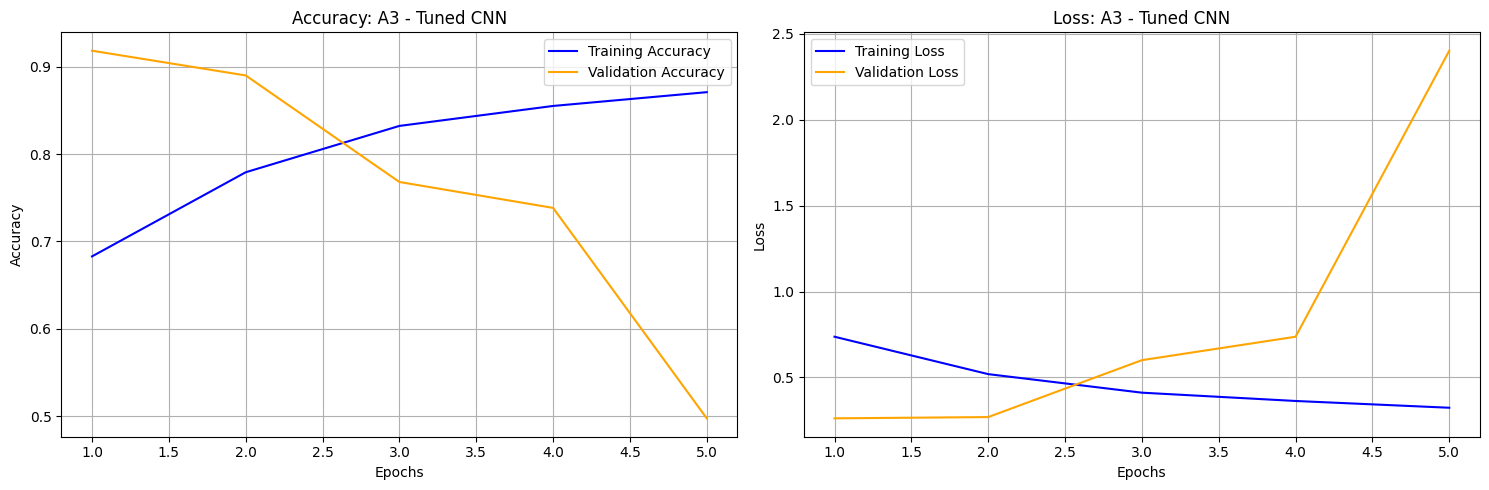

In [ ]:
plot_training_history(history_cnn_exp1, model_name="A3 - Tuned CNN")


Evaluating: A3 - Tuned CNN
94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step

Final Test Accuracy: 0.9163
Final F1 Score (Weighted): 0.9160

### Classification Report: A3 - Tuned CNN ###
              precision    recall  f1-score   support

   Karacadag       0.91      0.82      0.86       600
     Basmati       0.94      0.94      0.94       600
     Jasmine       0.97      0.99      0.98       600
     Arborio       0.94      0.90      0.92       600
      Ipsala       0.84      0.93      0.88       600

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.92      0.92      0.92      3000



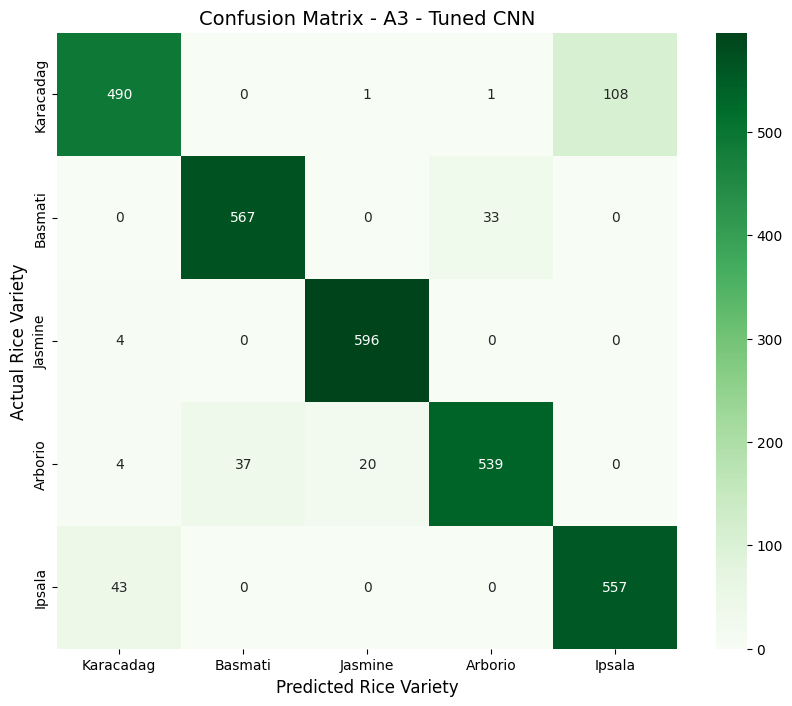

In [ ]:
evaluate_model(cnn_exp1_model, test_gen, "A3 - Tuned CNN", class_names=categories)


CNN Tuned: A4

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

def build_cnn_exp2():
    model = Sequential()

    # Block 1
    model.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(224,224,3)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))

    #Block 2
    model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))

    #Block 3
    model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))

    #Classifier
    model.add(Flatten())

    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))   # strong regularization

    model.add(Dense(5, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
cnn_exp2_model = build_cnn_exp2()
my_early_stop_1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)
history_cnn_exp2 = cnn_exp2_model.fit(
    train_gen,
    validation_data=validation_gen,
    epochs=15,
    callbacks=[my_early_stop_1]
)

Epoch 1/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 235s 515ms/step - accuracy: 0.6126 - loss: 1.2885 - val_accuracy: 0.5133 - val_loss: 3.9950
Epoch 2/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 213s 486ms/step - accuracy: 0.7975 - loss: 0.5241 - val_accuracy: 0.8597 - val_loss: 0.3996
Epoch 3/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 220s 501ms/step - accuracy: 0.8683 - loss: 0.3748 - val_accuracy: 0.8583 - val_loss: 0.4127
Epoch 4/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 217s 494ms/step - accuracy: 0.8939 - loss: 0.3080 - val_accuracy: 0.9493 - val_loss: 0.1336
Epoch 5/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 216s 493ms/step - accuracy: 0.9082 - loss: 0.2762 - val_accuracy: 0.9800 - val_loss: 0.0695
Epoch 6/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 205s 467ms/step - accuracy: 0.9154 - loss: 0.2485 - val_accuracy: 0.7483 - val_loss: 0.6260
Epoch 7/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 203s 463ms/step - accuracy: 0.9286 - loss: 0.2148 - val_accuracy: 0.9843 - val_loss: 0.0518
Epoch 8/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 202s 461ms/step - accuracy: 0.9273 -

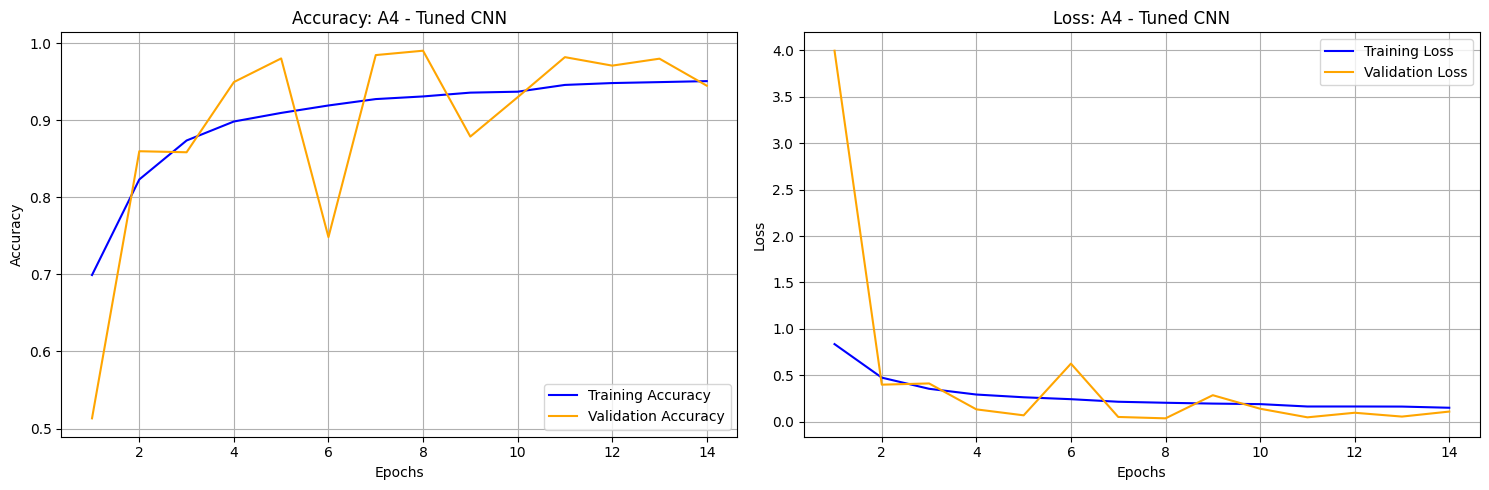

In [ ]:
plot_training_history(history_cnn_exp2, model_name="A4 - Tuned CNN")


Evaluating: A4 - Tuned CNN
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step

Final Test Accuracy: 0.9830
Final F1 Score (Weighted): 0.9829

### Classification Report: A4 - Tuned CNN ###
              precision    recall  f1-score   support

   Karacadag       0.98      0.98      0.98       600
     Basmati       0.97      0.99      0.98       600
     Jasmine       0.99      1.00      0.99       600
     Arborio       0.99      0.95      0.97       600
      Ipsala       0.99      0.99      0.99       600

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000



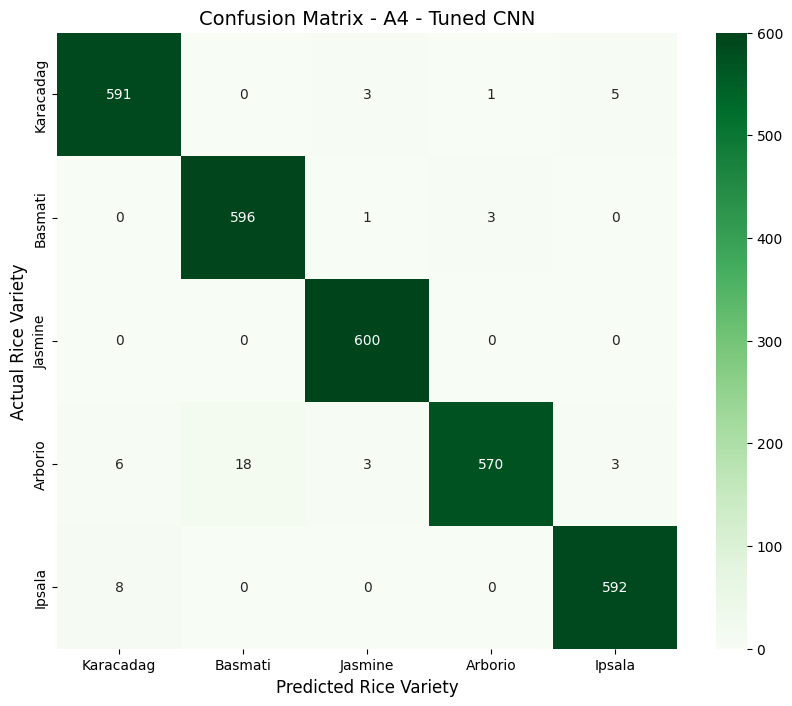

In [ ]:
evaluate_model(cnn_exp2_model, test_gen, "A4 - Tuned CNN", class_names=categories)


B1: MobileNetV2 Baseline

In [ ]:
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2

def build_mobilenet_baseline():
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Freeze ALL layers
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(5, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [ ]:
baseline_model = build_mobilenet_baseline()

history_baseline = baseline_model.fit(
    train_gen,
    validation_data=validation_gen,
    epochs=7
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/7


2026-04-15 12:11:13.119817: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-15 12:11:13.255980: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 27/438 ━━━━━━━━━━━━━━━━━━━━ 2:48 411ms/step - accuracy: 0.6632 - loss: 0.9057

2026-04-15 12:11:34.908525: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-15 12:11:35.045032: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.9018 - loss: 0.2750

2026-04-15 12:14:55.270462: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-15 12:14:55.407479: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


438/438 ━━━━━━━━━━━━━━━━━━━━ 239s 508ms/step - accuracy: 0.9019 - loss: 0.2747 - val_accuracy: 0.9453 - val_loss: 0.1463
Epoch 2/7
438/438 ━━━━━━━━━━━━━━━━━━━━ 199s 454ms/step - accuracy: 0.9600 - loss: 0.1105 - val_accuracy: 0.9650 - val_loss: 0.0904
Epoch 3/7
438/438 ━━━━━━━━━━━━━━━━━━━━ 195s 446ms/step - accuracy: 0.9649 - loss: 0.0972 - val_accuracy: 0.9600 - val_loss: 0.1129
Epoch 4/7
438/438 ━━━━━━━━━━━━━━━━━━━━ 194s 443ms/step - accuracy: 0.9636 - loss: 0.0981 - val_accuracy: 0.9743 - val_loss: 0.0658
Epoch 5/7
438/438 ━━━━━━━━━━━━━━━━━━━━ 199s 455ms/step - accuracy: 0.9657 - loss: 0.0961 - val_accuracy: 0.9300 - val_loss: 0.2049
Epoch 6/7
438/438 ━━━━━━━━━━━━━━━━━━━━ 192s 437ms/step - accuracy: 0.9680 - loss: 0.0891 - val_accuracy: 0.9087 - val_loss: 0.2812
Epoch 7/7
438/438 ━━━━━━━━━━━━━━━━━━━━ 193s 441ms/step - accuracy: 0.9706 - loss: 0.0784 - val_accuracy: 0.9593 - val_loss: 0.1156


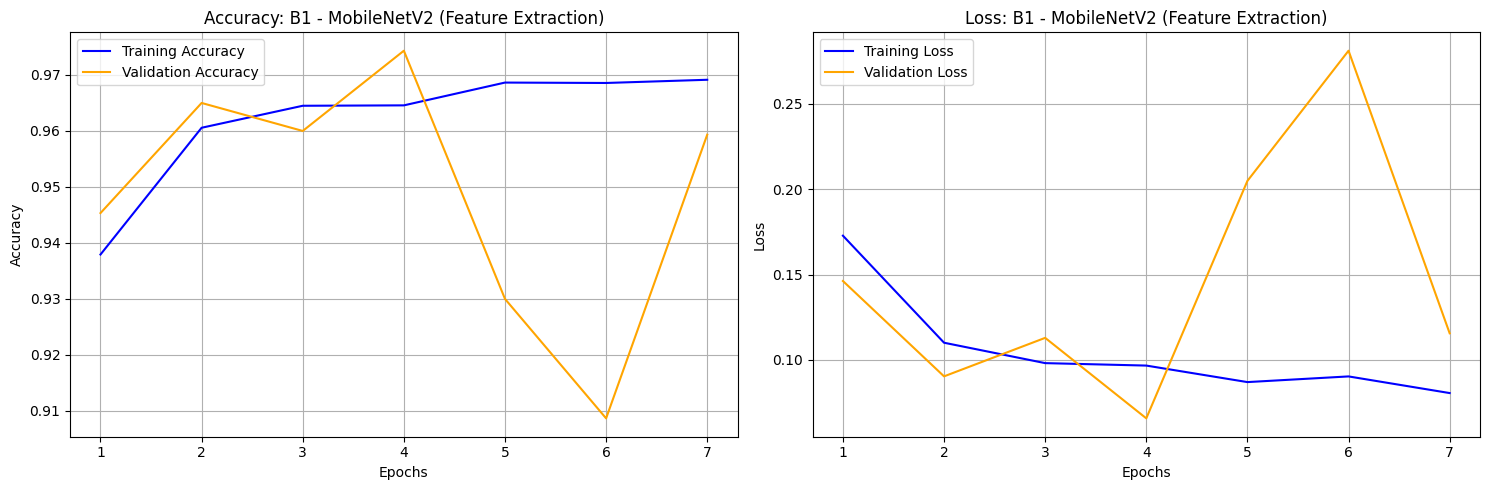

In [ ]:
plot_training_history(history_baseline, model_name="B1 - MobileNetV2 (Feature Extraction)")


Evaluating: B1 - MobileNet Baseline (Feature Extraction)
94/94 ━━━━━━━━━━━━━━━━━━━━ 16s 126ms/step

Final Test Accuracy: 0.9570
Final F1 Score (Weighted): 0.9569

### Classification Report: B1 - MobileNet Baseline (Feature Extraction) ###
              precision    recall  f1-score   support

   Karacadag       0.85      1.00      0.92       600
     Basmati       0.99      0.97      0.98       600
     Jasmine       1.00      0.99      1.00       600
     Arborio       0.97      0.98      0.98       600
      Ipsala       1.00      0.84      0.91       600

    accuracy                           0.96      3000
   macro avg       0.96      0.96      0.96      3000
weighted avg       0.96      0.96      0.96      3000



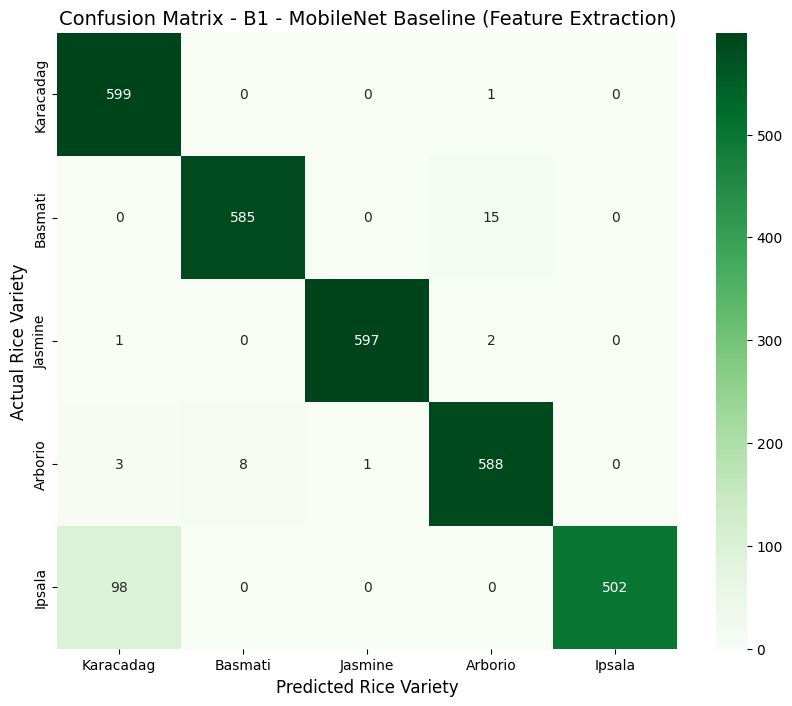

In [ ]:
evaluate_model(baseline_model, test_gen, "B1 - MobileNet Baseline (Feature Extraction)", class_names=categories)


B2: MobileNetV2 Tuned

In [ ]:
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.regularizers import l2

def build_mobilenet_exp1():
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Freeze base model
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),

        # Strong classifier
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
        layers.Dropout(0.5),

        layers.Dense(5, activation='softmax')
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
mnv_fine_v1_model = build_mobilenet_exp1()

history_mnv_fine_v1 = mnv_fine_v1_model.fit(
    train_gen,
    validation_data=validation_gen,
    epochs=15,
    callbacks=[my_early_stop]
)

Epoch 1/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 219s 477ms/step - accuracy: 0.8838 - loss: 0.7398 - val_accuracy: 0.9683 - val_loss: 0.3948
Epoch 2/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 196s 447ms/step - accuracy: 0.9434 - loss: 0.4729 - val_accuracy: 0.9490 - val_loss: 0.3829
Epoch 3/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 196s 447ms/step - accuracy: 0.9447 - loss: 0.3686 - val_accuracy: 0.9633 - val_loss: 0.2803
Epoch 4/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 199s 455ms/step - accuracy: 0.9469 - loss: 0.3161 - val_accuracy: 0.9503 - val_loss: 0.2889
Epoch 5/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 194s 443ms/step - accuracy: 0.9553 - loss: 0.2725 - val_accuracy: 0.9463 - val_loss: 0.2761
Epoch 6/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 190s 433ms/step - accuracy: 0.9549 - loss: 0.2526 - val_accuracy: 0.9623 - val_loss: 0.2197
Epoch 7/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 188s 430ms/step - accuracy: 0.9542 - loss: 0.2563 - val_accuracy: 0.9633 - val_loss: 0.2019
Epoch 8/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 183s 417ms/step - accuracy: 0.9575 -

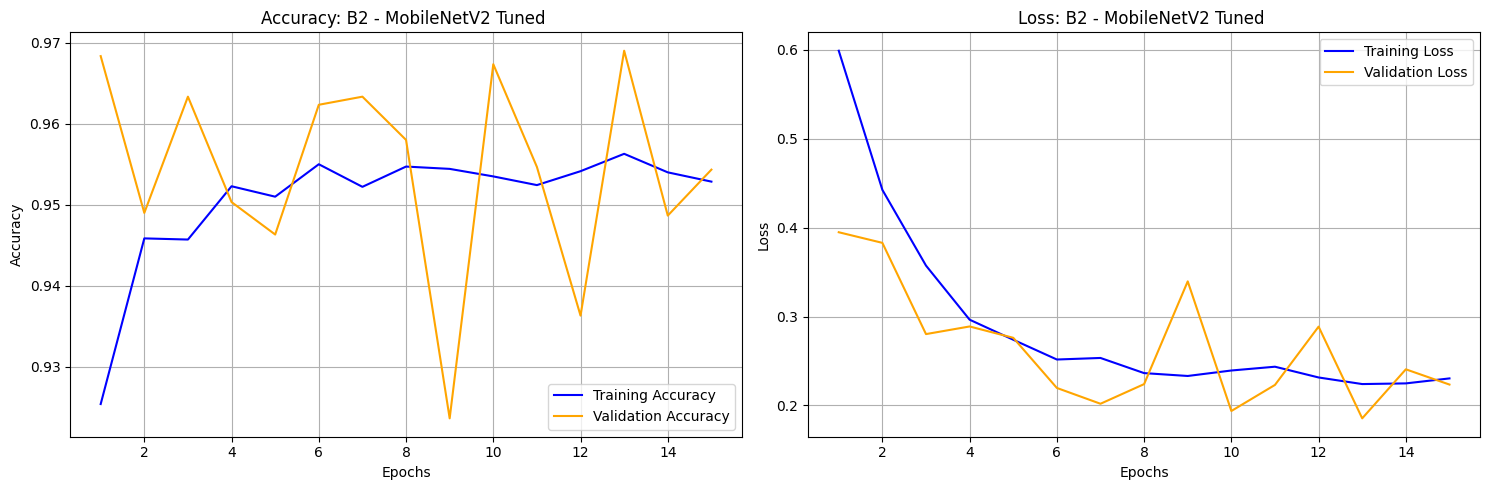

In [ ]:
plot_training_history(history_mnv_fine_v1, model_name="B2 - MobileNetV2 Tuned ")


Evaluating: B2- MobileNet Tune
94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 145ms/step

Final Test Accuracy: 0.9713
Final F1 Score (Weighted): 0.9714

### Classification Report: B2- MobileNet Tune ###
              precision    recall  f1-score   support

   Karacadag       0.95      0.99      0.97       600
     Basmati       1.00      0.94      0.97       600
     Jasmine       0.99      1.00      0.99       600
     Arborio       0.94      0.98      0.96       600
      Ipsala       1.00      0.95      0.97       600

    accuracy                           0.97      3000
   macro avg       0.97      0.97      0.97      3000
weighted avg       0.97      0.97      0.97      3000



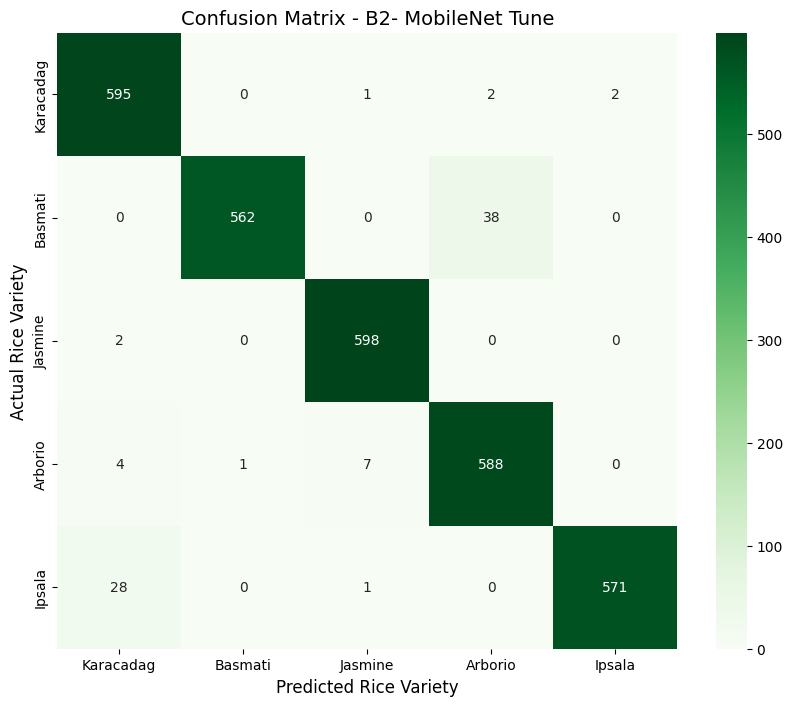

In [ ]:
evaluate_model(mnv_fine_v1_model, test_gen, "B2- MobileNet Tune", class_names=categories)

B3: MobileNetV2 Tuned - 80 layers Freeze

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import RMSprop

def build_mobilenet_exp_80():

    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Enable fine-tuning
    base_model.trainable = True

    #Freeze first 80 layers
    fine_tune_at = 80
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    # Build model
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(5, activation='softmax')
    ])

    model.compile(
        optimizer=RMSprop(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [ ]:
# Create model
mnv_fine_v2_80 = build_mobilenet_exp_80()

# Train model
history_mnv_80 = mnv_fine_v2_80.fit(
    train_gen,
    validation_data=validation_gen,
    epochs=15,
    callbacks=[my_early_stop]
)

Epoch 1/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 244s 512ms/step - accuracy: 0.6392 - loss: 0.9433 - val_accuracy: 0.7973 - val_loss: 0.6240
Epoch 2/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 201s 458ms/step - accuracy: 0.9435 - loss: 0.1716 - val_accuracy: 0.9553 - val_loss: 0.1673
Epoch 3/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 198s 452ms/step - accuracy: 0.9624 - loss: 0.1132 - val_accuracy: 0.9783 - val_loss: 0.0728
Epoch 4/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 204s 467ms/step - accuracy: 0.9668 - loss: 0.0921 - val_accuracy: 0.9853 - val_loss: 0.0429
Epoch 5/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 202s 460ms/step - accuracy: 0.9784 - loss: 0.0693 - val_accuracy: 0.9870 - val_loss: 0.0384
Epoch 6/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 202s 462ms/step - accuracy: 0.9776 - loss: 0.0656 - val_accuracy: 0.9850 - val_loss: 0.0424
Epoch 7/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 200s 456ms/step - accuracy: 0.9820 - loss: 0.0510 - val_accuracy: 0.9743 - val_loss: 0.0814
Epoch 8/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 200s 457ms/step - accuracy: 0.9833 -

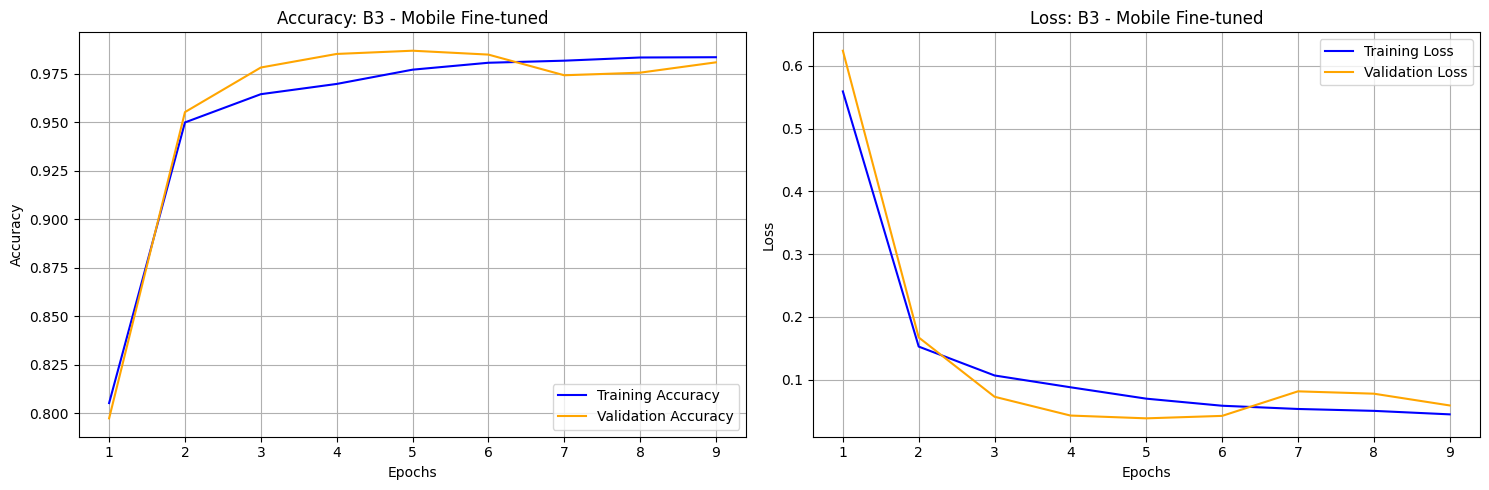

In [ ]:
plot_training_history(history_mnv_80, model_name="B3 - Mobile Fine-tuned")


Evaluating: B3- MobileNet Fine-Tuned
94/94 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step

Final Test Accuracy: 0.9903
Final F1 Score (Weighted): 0.9903

### Classification Report: B3- MobileNet Fine-Tuned ###
              precision    recall  f1-score   support

   Karacadag       0.98      0.99      0.99       600
     Basmati       1.00      0.99      0.99       600
     Jasmine       0.99      1.00      1.00       600
     Arborio       0.98      0.99      0.99       600
      Ipsala       1.00      0.98      0.99       600

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



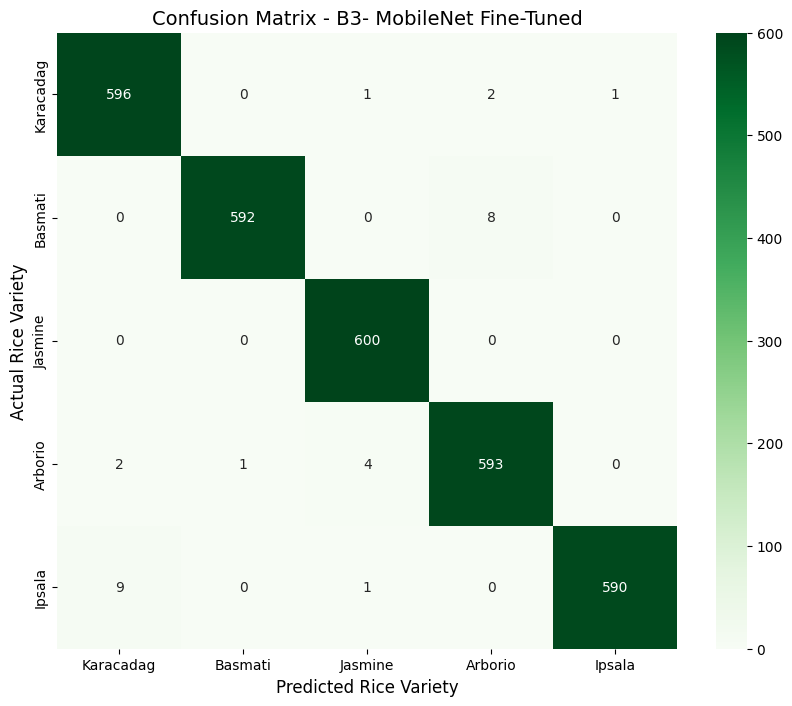

In [ ]:
evaluate_model(mnv_fine_v2_80, test_gen, "B3- MobileNet Fine-Tuned", class_names=categories)

B4: MobileNetV2 Tuned - 100 layers Freeze




In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import RMSprop

def build_mobilenet_exp2():
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Enable training
    base_model.trainable = True

    # Freeze early layers
    fine_tune_at = 100
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(5, activation='softmax')
    ])

    model.compile(
        optimizer=RMSprop(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
mnv_fine_v2_model = build_mobilenet_exp2()

history_mnv_fine_v2 = mnv_fine_v2_model.fit(
    train_gen,
    validation_data=validation_gen,
    epochs=15,
    callbacks=[my_early_stop]
)

Epoch 1/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 239s 505ms/step - accuracy: 0.6633 - loss: 0.9021 - val_accuracy: 0.9330 - val_loss: 0.3426
Epoch 2/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 198s 453ms/step - accuracy: 0.9319 - loss: 0.1916 - val_accuracy: 0.9677 - val_loss: 0.1367
Epoch 3/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 197s 450ms/step - accuracy: 0.9513 - loss: 0.1444 - val_accuracy: 0.9797 - val_loss: 0.0735
Epoch 4/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 201s 459ms/step - accuracy: 0.9575 - loss: 0.1194 - val_accuracy: 0.9807 - val_loss: 0.0568
Epoch 5/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 203s 464ms/step - accuracy: 0.9667 - loss: 0.0931 - val_accuracy: 0.9833 - val_loss: 0.0468
Epoch 6/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 200s 456ms/step - accuracy: 0.9690 - loss: 0.0882 - val_accuracy: 0.9837 - val_loss: 0.0502
Epoch 7/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 203s 464ms/step - accuracy: 0.9735 - loss: 0.0772 - val_accuracy: 0.9797 - val_loss: 0.0593
Epoch 8/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 198s 452ms/step - accuracy: 0.9728 -

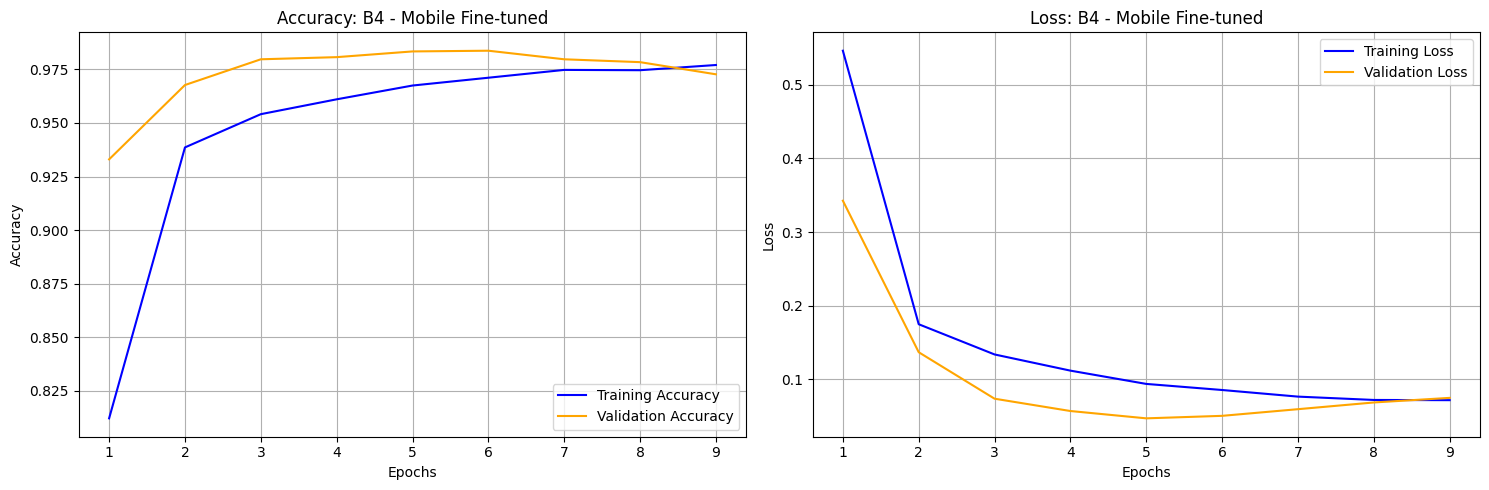

In [ ]:
plot_training_history(history_mnv_fine_v2, model_name="B4 - Mobile Fine-tuned")


Evaluating: B4- MobileNet Fine-Tuned
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step

Final Test Accuracy: 0.9853
Final F1 Score (Weighted): 0.9853

### Classification Report: B4- MobileNet Fine-Tuned ###
              precision    recall  f1-score   support

   Karacadag       0.98      0.99      0.99       600
     Basmati       0.99      0.98      0.98       600
     Jasmine       0.99      1.00      0.99       600
     Arborio       0.98      0.97      0.98       600
      Ipsala       0.99      0.98      0.99       600

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



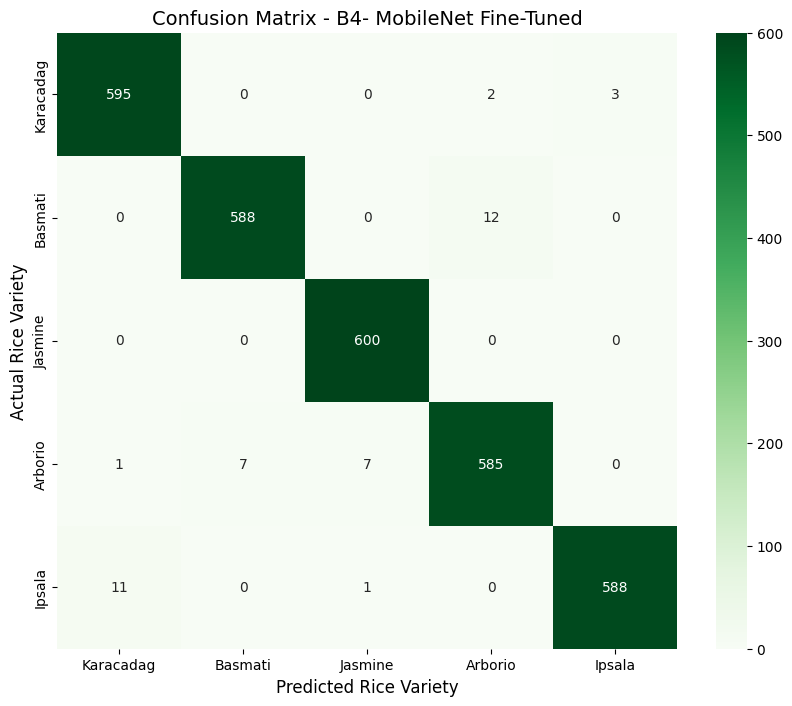

In [ ]:
evaluate_model(mnv_fine_v2_model, test_gen, "B4- MobileNet Fine-Tuned", class_names=categories)

B5: MobileNetV2 Tuned - Full fine-tuning

In [ ]:
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2

def build_mobilenet_exp3():
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Full fine-tuning (all layers trainable)
    base_model.trainable = True

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(5, activation='softmax')
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
mnv_exp3_model = build_mobilenet_exp3()

history_mnv_exp3 = mnv_exp3_model.fit(
    train_gen,
    validation_data=validation_gen,
    epochs=15,
    callbacks=[my_early_stop]
)

Epoch 1/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 286s 541ms/step - accuracy: 0.6280 - loss: 0.9997 - val_accuracy: 0.4763 - val_loss: 1.5486
Epoch 2/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 208s 474ms/step - accuracy: 0.9583 - loss: 0.1434 - val_accuracy: 0.5710 - val_loss: 1.2874
Epoch 3/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 211s 481ms/step - accuracy: 0.9758 - loss: 0.0829 - val_accuracy: 0.7243 - val_loss: 0.7759
Epoch 4/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 218s 499ms/step - accuracy: 0.9780 - loss: 0.0667 - val_accuracy: 0.8663 - val_loss: 0.3468
Epoch 5/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 230s 525ms/step - accuracy: 0.9827 - loss: 0.0535 - val_accuracy: 0.9427 - val_loss: 0.1659
Epoch 6/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 232s 530ms/step - accuracy: 0.9833 - loss: 0.0491 - val_accuracy: 0.9503 - val_loss: 0.1401
Epoch 7/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 225s 513ms/step - accuracy: 0.9899 - loss: 0.0332 - val_accuracy: 0.9623 - val_loss: 0.1171
Epoch 8/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 223s 509ms/step - accuracy: 0.9883 -

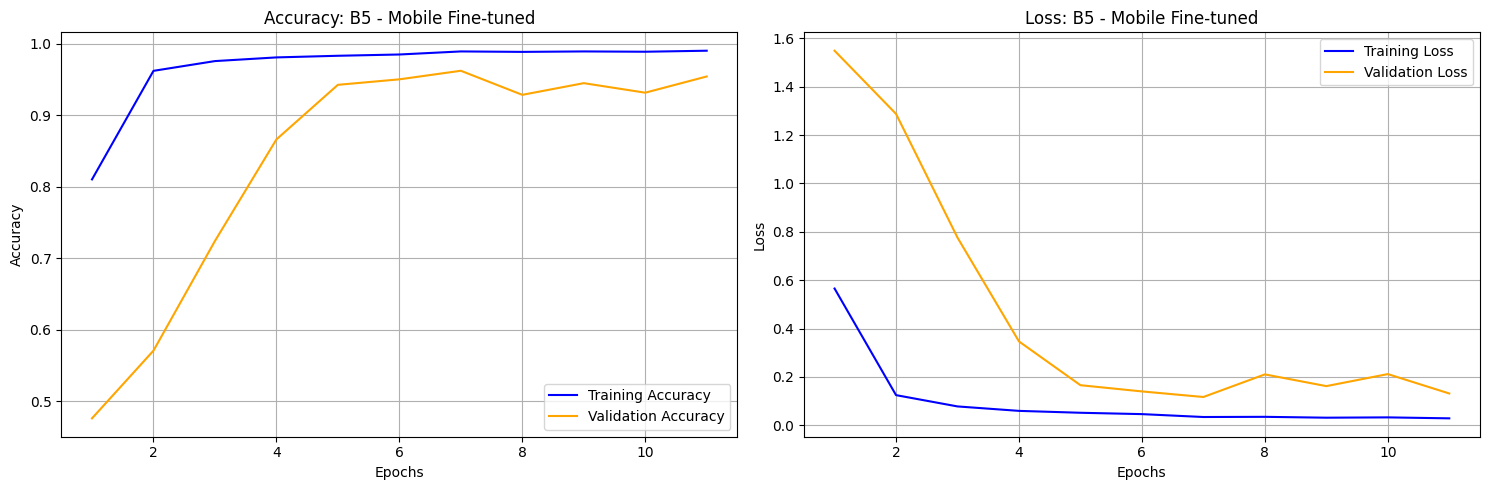

In [ ]:
plot_training_history(history_mnv_exp3, model_name="B5 - Mobile Fine-tuned")


Evaluating: B5- MobileNet Fine-Tuned
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step

Final Test Accuracy: 0.9617
Final F1 Score (Weighted): 0.9615

### Classification Report: B5- MobileNet Fine-Tuned ###
              precision    recall  f1-score   support

   Karacadag       0.88      0.99      0.93       600
     Basmati       0.99      0.98      0.98       600
     Jasmine       0.99      1.00      0.99       600
     Arborio       0.97      0.98      0.98       600
      Ipsala       1.00      0.86      0.92       600

    accuracy                           0.96      3000
   macro avg       0.96      0.96      0.96      3000
weighted avg       0.96      0.96      0.96      3000



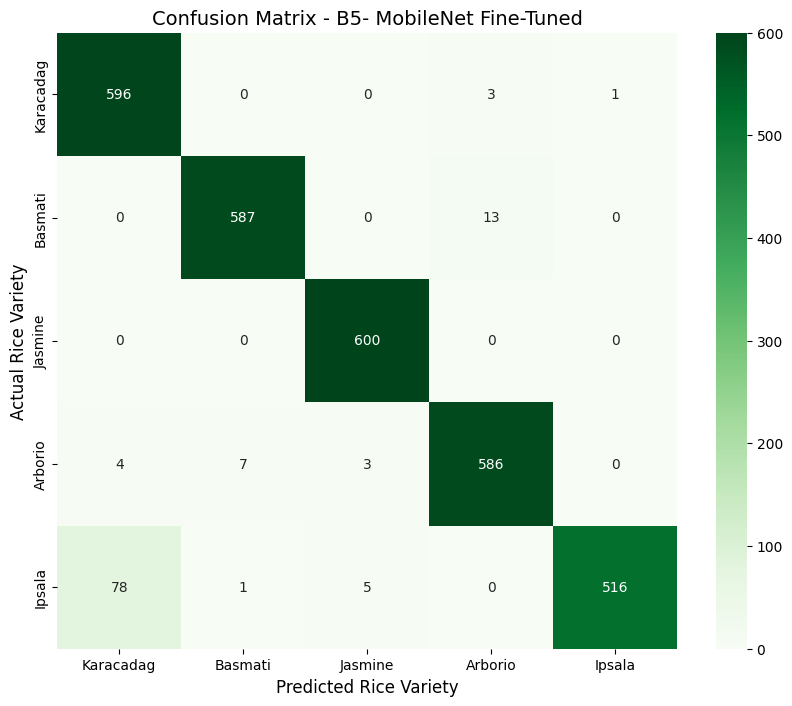

In [ ]:
evaluate_model(mnv_exp3_model, test_gen, "B5- MobileNet Fine-Tuned", class_names=categories)

Model Comparision

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

models_to_test = {
    "A1:CNN Baseline":cnn_model,
    "A2: CNN-Tuned":cnn_exp_model,
    "A3: CNN-Tuned": cnn_exp1_model,
    "A4: CNN-Tuned":cnn_exp2_model,
    "B1: MobileNetV2-Baseline": baseline_model,
    "B2: MobileNetV2-Tuned":mnv_fine_v1_model,
    "B3: MobileNetV2-Tuned": mnv_fine_v2_80,
    "B4: MobileNetV2":mnv_fine_v2_model,
    "B5: MobileNetV2":mnv_exp3_model
}

results = []

print("\n===== CLEAN TEST EVALUATION =====")

for name, model in models_to_test.items():
    print(f"Evaluating {name}...")

    loss, acc = model.evaluate(test_gen, verbose=0)

    results.append({
        "Model": name,
        "Test Accuracy": acc,
        "Test Loss": loss
    })

df_results = pd.DataFrame(results).sort_values(by="Test Accuracy", ascending=False)

print(df_results)



===== CLEAN TEST EVALUATION =====
Evaluating A1:CNN Baseline...
Evaluating A2: CNN-Tuned...
Evaluating A3: CNN-Tuned...
Evaluating A4: CNN-Tuned...
Evaluating B1: MobileNetV2-Baseline...
Evaluating B2: MobileNetV2-Tuned...
Evaluating B3: MobileNetV2-Tuned...
Evaluating B4: MobileNetV2...
Evaluating B5: MobileNetV2...
                      Model  Test Accuracy  Test Loss
6     B3: MobileNetV2-Tuned       0.990333   0.031379
7           B4: MobileNetV2       0.985333   0.043435
3             A4: CNN-Tuned       0.983000   0.050932
1             A2: CNN-Tuned       0.976000   0.076768
5     B2: MobileNetV2-Tuned       0.971333   0.181984
8           B5: MobileNetV2       0.961667   0.098617
4  B1: MobileNetV2-Baseline       0.957000   0.119745
0           A1:CNN Baseline       0.945333   0.149389
2             A3: CNN-Tuned       0.916333   0.272909


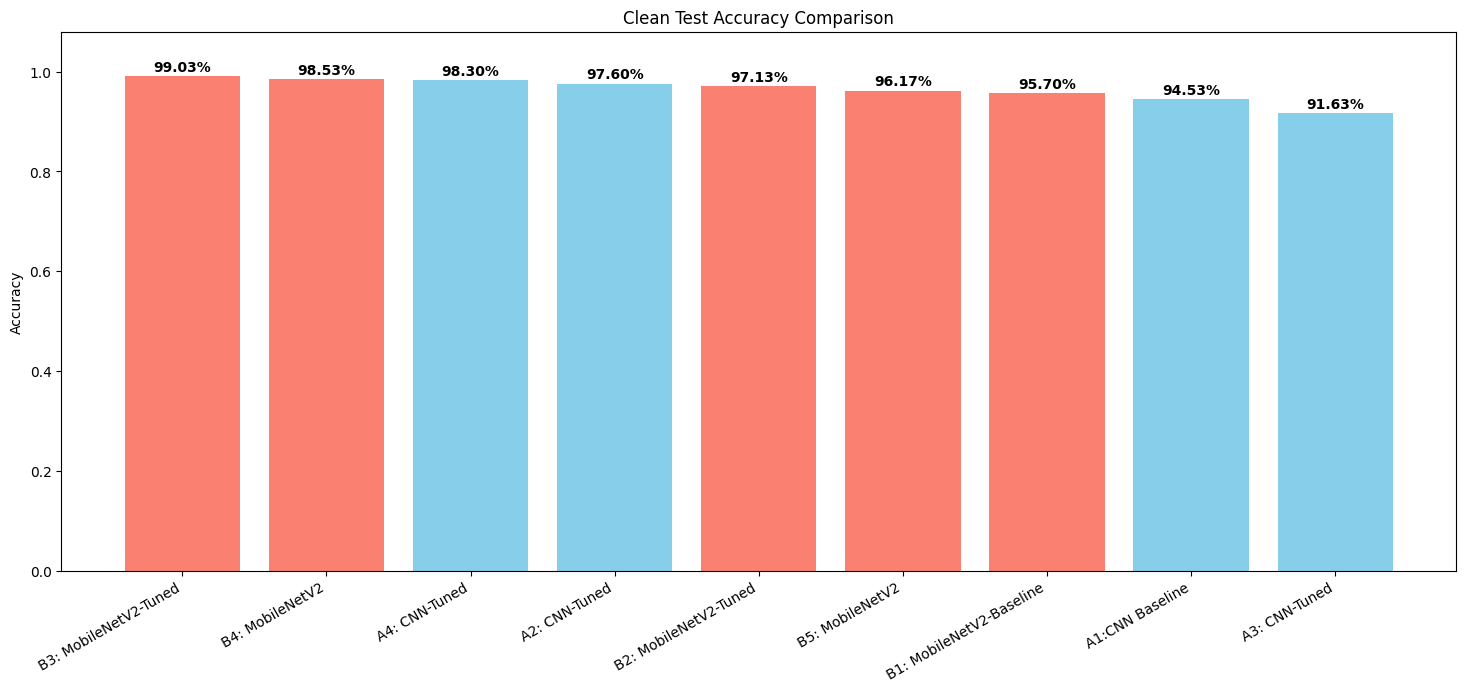

In [ ]:
colors = []

for model_name in df_results["Model"]:
    if "CNN" in model_name:
        colors.append("skyblue")   # CNN color
    else:
        colors.append("salmon")    # MobileNet color

plt.figure(figsize=(18,7))

bars = plt.bar(df_results["Model"],
               df_results["Test Accuracy"],
               color=colors)

plt.title("Clean Test Accuracy Comparison")
plt.xticks(rotation=30, ha='right')
plt.ylabel("Accuracy")
plt.ylim(0, 1)

# ======================================================
# ADD PERCENTAGE ON TOP
# ======================================================
for bar in bars:
    height = bar.get_height()
    plt.ylim(0, 1.08)   # 👈 increase headroom
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.2%}",   # percentage format
        ha='center',
        fontweight='bold'
    )

plt.show()

Robustness Analysis

Found 3000 validated image filenames belonging to 5 classes.
--- Starting Robustness Evaluation on Unseen Noisy Data ---
Stress testing A4: CNN-Tuned (Best Tuned Model)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


47/47 ━━━━━━━━━━━━━━━━━━━━ 40s 844ms/step - accuracy: 0.8616 - loss: 0.5777
Stress testing B3: MobileNetV2-Tuned(Best Tuned Model)...
47/47 ━━━━━━━━━━━━━━━━━━━━ 41s 873ms/step - accuracy: 0.9244 - loss: 0.2423


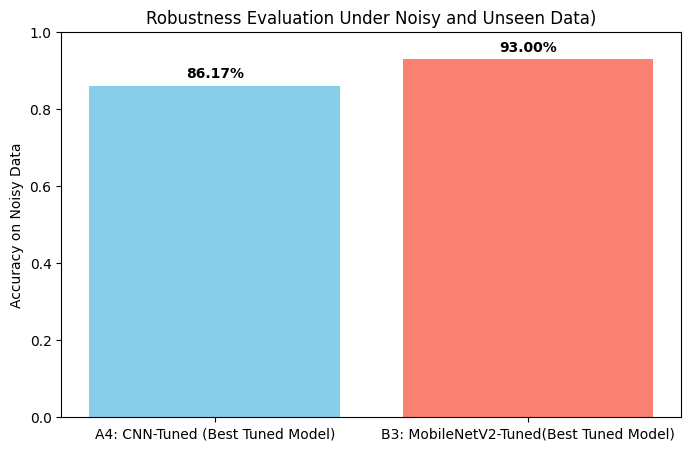

In [ ]:
# 1. Create the Robust (Noisy) Generator
# Note: We do NOT use validation_split here because we are using our custom test_df
robust_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=90,          # Extreme rotation
    brightness_range=[0.4, 1.4], # Dim to very bright
    zoom_range=0.3,              # Scaling issues
    horizontal_flip=True,
    vertical_flip=True
)

# 2. Link it to the TEST DATAFRAME (The 15% unseen data)
robust_test_gen = robust_datagen.flow_from_dataframe(
    test_df, # <--- CRITICAL: Use the unseen 15% test data
    x_col='path',
    y_col='category',
    target_size=IMG_SIZE,
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

# 3. List of models to compare
eval_models = {
    "A4: CNN-Tuned (Best Tuned Model)": cnn_exp2_model,
    "B3: MobileNetV2-Tuned(Best Tuned Model)": mnv_fine_v2_80
}

# --- 4. Evaluation Loop ---
print("--- Starting Robustness Evaluation on Unseen Noisy Data ---")
robust_results = {}

for name, model in eval_models.items():
    print(f"Stress testing {name}...")
    loss, acc = model.evaluate(robust_test_gen)
    robust_results[name] = acc

# --- 5. Visualization (Your bar chart logic is already good!) ---
res_df = pd.DataFrame(list(robust_results.items()), columns=['Model', 'Robust Accuracy'])

plt.figure(figsize=(8, 5))
plt.bar(res_df['Model'], res_df['Robust Accuracy'], color=['skyblue', 'salmon'])
plt.ylabel('Accuracy on Noisy Data')
plt.title('Robustness Evaluation Under Noisy and Unseen Data)')
plt.ylim(0, 1.0)
for i, v in enumerate(res_df['Robust Accuracy']):
    plt.text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')
plt.show()



===== CONFUSION MATRIX: MobileNetV2 Fine-Tuned (Best) =====
94/94 ━━━━━━━━━━━━━━━━━━━━ 21s 221ms/step


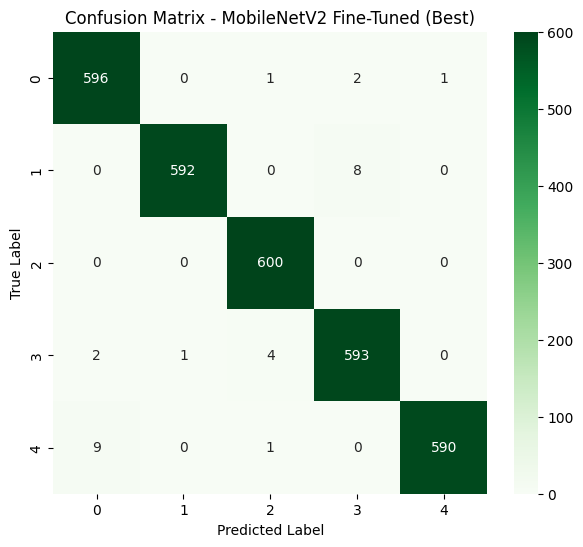


===== CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       600
           1       1.00      0.99      0.99       600
           2       0.99      1.00      1.00       600
           3       0.98      0.99      0.99       600
           4       1.00      0.98      0.99       600

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ======================================================
# 1. MANUALLY SELECT BEST MODEL
# ======================================================
best_model = mnv_fine_v2_80   # <-- change this to your best model
best_model_name = "MobileNetV2 Fine-Tuned (Best)"

print(f"\n===== CONFUSION MATRIX: {best_model_name} =====")

# ======================================================
# 2. PREDICTIONS
# ======================================================
test_gen.reset()

y_pred = np.argmax(best_model.predict(test_gen), axis=1)
y_true = test_gen.classes

# ======================================================
# 3. CONFUSION MATRIX
# ======================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# ======================================================
# 4. CLASSIFICATION REPORT
# ======================================================
print("\n===== CLASSIFICATION REPORT =====\n")
print(classification_report(y_true, y_pred))